In [14]:
import pandas as pd
import numpy as np

# Step 1: Load the dataset directly from the online source
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

# Convert 'TotalCharges' column to numeric, forcing non-numeric strings to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing NaN values in 'TotalCharges' with the column's median value
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Step 2: Encode the categorical target column 'Churn' into binary 1s and 0s
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

/tmp/ipykernel_851/856542938.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [17]:
# Identify all object (categorical) columns, discarding the unique identifier 'customerID'
cat_cols = df.select_dtypes(include='object').columns.drop('customerID')

# Generate dummy indicator variables, dropping the first category to avoid redundancy
df_encoded = pd.get_dummies(df.drop('customerID', axis=1), columns=cat_cols, drop_first=True)

In [20]:
from sklearn.model_selection import train_test_split

# Isolate feature matrix X and target vector y
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Split into 80% training and 20% testing subsets with random_state for consistency
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [21]:
from sklearn.preprocessing import StandardScaler

# Initialize the standardizer
scaler = StandardScaler()

# Define the explicit numerical columns to scale
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Fit and transform on the training set, and transform the testing set
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Data preparation complete!")
print("Train features shape:", X_train.shape)
print("Test features shape:", X_test.shape)

Data preparation complete!
Train features shape: (5634, 30)
Test features shape: (1409, 30)


In [22]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# max_iter=1000 ensures the optimization algorithm has enough iterations to converge
model = LogisticRegression(max_iter=1000)

# Fit the model on the stratified and scaled training data
model.fit(X_train, y_train)

# Generate hard class predictions (0 or 1) for evaluation
y_pred = model.predict(X_test)

# Generate soft probability scores for class 1 (Churn), useful for ROC/AUC curves
y_proba = model.predict_proba(X_test)[:, 1]

print("Model training complete!")
print("Initial predictions array slice:", y_pred[:10])


Model training complete!
Initial predictions array slice: [0 1 0 0 0 1 0 0 0 0]


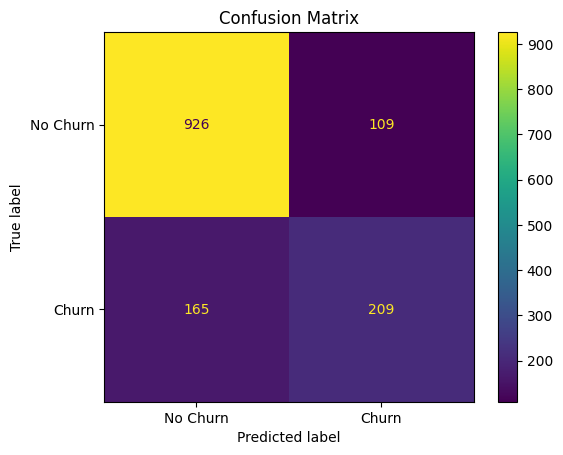

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Display the confusion matrix directly using the trained model and test data
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    display_labels=['No Churn', 'Churn']
)

# Set title and render the plot
plt.title('Confusion Matrix')
plt.show()

In [24]:
from sklearn.metrics import classification_report

# Generate text report showing main classification metrics per target class
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



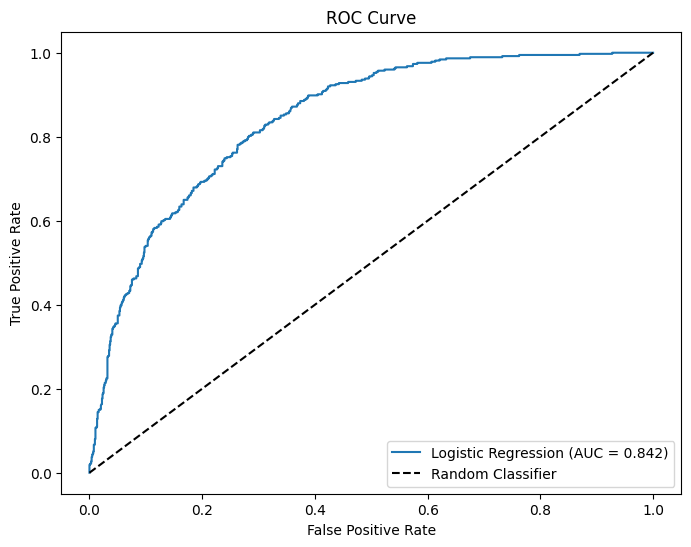

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score

# Compute False Positive Rates, True Positive Rates, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Compute Area Under the Receiver Operating Characteristic Curve (ROC AUC)
auc = roc_auc_score(y_test, y_proba)

# Initialize the canvas size
plt.figure(figsize=(8, 6))

# Plot the model's ROC performance curve
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})')

# Plot a diagonal baseline representing a completely random guessing classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Format plot decorations and descriptions
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

Step 4 — Business Analysis of Model Errors:

False Positives (Top-Right Quadrant): These represent users who were flagged as likely to churn but actually intended to stay. In business terms, targeting them with retention discounts or proactive customer support calls incurs a minor financial cost (marketing spend), but preserves their overall satisfaction.

False Negatives (Bottom-Left Quadrant): These represent users whom the model predicted would stay, but who subsequently closed their accounts. In business terms, this error is far more costly because these customers are lost completely without giving the company a chance to intervene or offer custom incentives.